In [2]:
# Path to your processed GeoPackage
import geopandas as gpd
import pandas as pd

path_gpkg = "../Data/Shapefiles/APES_metric.gpkg"

g = gpd.read_file(path_gpkg, layer="nuts3")

print("Raw rows:", len(g))
print("Unique NUTS_CODE (raw):", g['NUTS_CODE'].nunique())

# 1) Universe of NUTS with a single geometry per code
g_universe = (
    g.loc[~g.geometry.is_empty, ['NUTS_CODE', 'NUTS_NAME', 'geometry']]
      .dissolve(by='NUTS_CODE', as_index=False)
)

print("Universe NUTS (non-empty geometries):", g_universe.shape[0])

# 2) Filter out ZIKV and keep non-empty geometries
g_filt = g.loc[(~g.geometry.is_empty) & (g["RecordType"] != "ZIKV")].copy()
print("Filtered rows:", len(g_filt))
print("Filtered unique NUTS_CODE:", g_filt['NUTS_CODE'].nunique())

# Lost NUTS (for transparency)
lost_codes = sorted(set(g_universe['NUTS_CODE']) - set(g_filt['NUTS_CODE']))
print("NUTS with no non-ZIKV records:", len(lost_codes))

covariates = [
    "Forest", "Shrub", "Urban", "Crop", "Water", "Other",
    "Mean_P_Winter", "Max_WD_Winter", "Max_DD_Winter",
    "Mean_T_Spring", "Max_DD_Spring",
    "Mean_T_Summer",
    "Max_WD_Autumn", "Max_DD_Autumn",
    "gdp", "pop_dens"
]

value_cols = ['incidence'] + covariates

# 3) Aggregate attributes by NUTS_CODE
agg = (
    g_filt.groupby('NUTS_CODE')[value_cols]
         .sum()
         .reset_index()
)

# 4) Left-join back onto the full universe and fill missing with 0
g_out = g_universe.merge(agg, on='NUTS_CODE', how='left')
g_out[value_cols] = g_out[value_cols].fillna(0)

# Final GeoDataFrame in projected CRS
gdf = gpd.GeoDataFrame(g_out, geometry="geometry", crs=g.crs)
gdf = gdf.to_crs(32633)

print("Final NUTS in model:", len(gdf))


Raw rows: 1858
Unique NUTS_CODE (raw): 1460
Universe NUTS (non-empty geometries): 1174
Filtered rows: 1363
Filtered unique NUTS_CODE: 1174
NUTS with no non-ZIKV records: 0
Final NUTS in model: 1174


# Correlation

In [36]:
from sklearn.preprocessing import StandardScaler
from spreg import OLS  # pip install pysal spreg
from libpysal.weights import DistanceBand, lag_spatial, KNN
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import statsmodels.api as sm

scaler = StandardScaler()
X_std = scaler.fit_transform(gdf[covariates].to_numpy())
X_std_df = pd.DataFrame(X_std, columns=covariates, index=gdf.index)


corr = X_std_df.corr()
high_corr = [(c1, c2, corr.loc[c1, c2]) 
             for c1 in corr.columns
             for c2 in corr.columns
             if (c1 < c2 and abs(corr.loc[c1, c2]) > 0.7)]

high_corr


[('Max_WD_Winter', 'Mean_P_Winter', 0.8355326421242976),
 ('Max_DD_Winter', 'Mean_T_Spring', 0.9173733365368333),
 ('Max_DD_Winter', 'Mean_T_Summer', 0.9256736336297217),
 ('Mean_T_Spring', 'Mean_T_Summer', 0.9954230382206949),
 ('Max_DD_Spring', 'Max_DD_Winter', 0.7454149209810498),
 ('Max_DD_Spring', 'Mean_T_Spring', 0.7722675194242324),
 ('Max_DD_Spring', 'Mean_T_Summer', 0.7883433263359291),
 ('Max_WD_Autumn', 'Mean_P_Winter', 0.7525945405921572),
 ('Max_WD_Autumn', 'Max_WD_Winter', 0.7865527183916862),
 ('Max_DD_Autumn', 'Max_DD_Winter', 0.8962649047160255),
 ('Max_DD_Autumn', 'Mean_T_Spring', 0.9320504848828537),
 ('Max_DD_Autumn', 'Mean_T_Summer', 0.9319215386499281)]

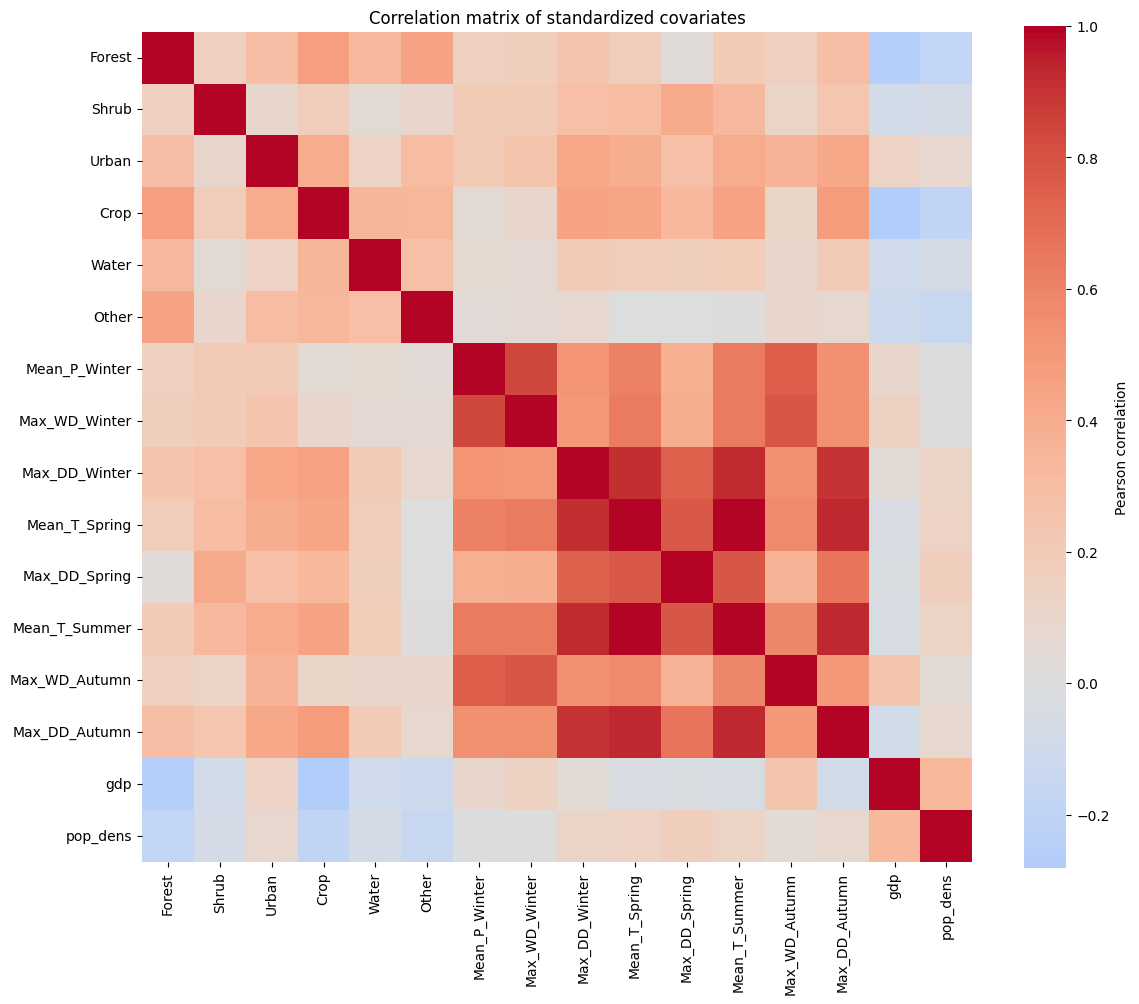

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

f,ax=plt.subplots(figsize=(12,10))
sns.heatmap(X_std_df.corr(), 
            cmap="coolwarm", 
            center=0, 
            annot=False, 
            square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix of standardized covariates")
plt.tight_layout()
plt.show()

In [40]:
f.savefig('../Figures/corrMatrix.png', dpi=300, bbox_inches='tight')
f.savefig('../Figures/corrMatrix.pdf', dpi=300, bbox_inches='tight')

# VIF 

In [3]:


scaler = StandardScaler()
X_std = scaler.fit_transform(gdf[covariates].to_numpy())

from statsmodels.stats.outliers_influence import variance_inflation_factor

# DataFrame con le covariate standardizzate
X_vif = pd.DataFrame(X_std, columns=covariates)

vif_df = pd.DataFrame({
    "variable": covariates,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Ordina dal VIF più alto al più basso
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_df)


,variable,VIF
0,Mean_T_Summer,187.939716
1,Mean_T_Spring,144.863121
2,Max_DD_Autumn,10.794593
3,Max_DD_Winter,10.639791
4,Max_WD_Winter,5.142850
5,Mean_P_Winter,4.341248
6,Max_DD_Spring,3.839001
7,Max_WD_Autumn,3.607323
8,Crop,2.238789
9,Forest,1.889990


# Weighted Distance

In [31]:
X_raw = gdf[covariates].to_numpy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

X_std_df = pd.DataFrame(X_std, columns=covariates, index=gdf.index)
y = gdf["incidence"].to_numpy().reshape(-1, 1)

# Weights summary

In [34]:
from libpysal.weights import DistanceBand

distances = [100000, 125000, 150000, 175000, 200000]

weights_summary = []

for d in distances:
    W = DistanceBand(coords, threshold=d, binary=True, silence_warnings=True)
    W.transform = "R"  # row-standardize

    neigh_counts = np.array([len(neigh) for neigh in W.neighbors.values()])
    n_islands = len(W.islands)  # regions with 0 neighbors

    weights_summary.append({
        "d_m": d,
        "mean_neighbors": neigh_counts.mean(),
        "min_neighbors": neigh_counts.min(),
        "max_neighbors": neigh_counts.max(),
        "n_islands": n_islands
        # optionally:
        # "n_components": len(set(W.component_labels)) if hasattr(W, "component_labels") else None
    })

weights_summary = pd.DataFrame(weights_summary)
print(weights_summary)


      d_m  mean_neighbors  min_neighbors  max_neighbors  n_islands
0  100000       18.321976              0             59         28
1  125000       27.776831              0             81          6
2  150000       38.928450              0            114          4
3  175000       51.776831              0            144          3
4  200000       66.233390              0            188          2


# Moran's I

In [35]:
import statsmodels.api as sm
from esda.moran import Moran
from libpysal.weights import DistanceBand

y_raw = gdf["incidence"].to_numpy().reshape(-1, 1)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

X_std_df = pd.DataFrame(X_std, columns=covariates, index=gdf.index)
X_ols = sm.add_constant(X_std_df.to_numpy())


coords = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])

distances = [100000, 125000, 150000, 175000, 200000]

moran_summary = []

for d in distances:
    W = DistanceBand(coords, threshold=d, binary=True, silence_warnings=True)
    W.transform = "R"
    
    y_lag = lag_spatial(W, y_raw.ravel()).reshape(-1, 1)
    Wy_z = (y_lag - y_lag.mean(axis=0)) / y_lag.std(axis=0, ddof=0)

    ols_model = sm.OLS(Wy_z, X_ols).fit()
    ols_resid = ols_model.resid

    moran_res = Moran(ols_resid, W)
    moran_summary.append({
        "d_m": d,
        "moran_I": moran_res.I,
        "p_sim": moran_res.p_sim
    })

moran_summary = pd.DataFrame(moran_summary)
print(moran_summary)

      d_m   moran_I  p_sim
0  100000  0.570303  0.001
1  125000  0.555243  0.001
2  150000  0.496155  0.001
3  175000  0.468991  0.001
4  200000  0.466826  0.001


# GWR VS d

In [33]:
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

gwr_summary = []

for d in distances:
    # still only used to measure residual spatial autocorrelation
    W = DistanceBand(coords, threshold=d, binary=True, silence_warnings=True)
    W.transform = "R"

    X_gwr = X_std_df.to_numpy()

    bw = Sel_BW(coords, y, X_gwr, kernel="exponential", fixed=False).search()
    gwr_fit = GWR(
        coords, y, X_gwr, bw,
        kernel="exponential",
        fixed=False,
        constant=True
    ).fit()

    moran_gwr = Moran(gwr_fit.resid_response, W)

    gwr_summary.append({
        "d_m": d,
        "bw_selected": bw,
        "AICc": gwr_fit.aicc,
        "moran_resid_I": moran_gwr.I,
        "moran_resid_p": moran_gwr.p_sim
    })

gwr_summary = pd.DataFrame(gwr_summary)
print(gwr_summary)


      d_m  bw_selected          AICc  moran_resid_I  moran_resid_p
0  100000         77.0 -14040.548317       0.025090          0.023
1  125000         77.0 -14040.548317       0.007190          0.167
2  150000         77.0 -14040.548317       0.003328          0.264
3  175000         77.0 -14040.548317       0.002693          0.271
4  200000         77.0 -14040.548317       0.004218          0.183
